## Wave Raw Data Analysis and Processing
Use this notebook to check fields in the raw netcdf files and to test processing code.

In [2]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs

### Save max energy wave fields

In [ ]:
### Generate maxe data
ds = xr.open_dataset('/Users/jwu/Work/Code/wavecnn/data/202109.nc')
hs = np.swapaxes(ds.hs.values, 0, 1)
lp = np.swapaxes(ds.lp.values, 0, 1)
dm = np.swapaxes(ds.dm.values, 0, 1)
dspr = np.swapaxes(ds.dspr.values, 0, 1)
hs_fill = np.nan_to_num(hs, nan=0.0)   

wave_max = np.zeros((hs.shape[0], 4, hs.shape[-2], hs.shape[-1]))
for i in range(hs.shape[0]):
    max_hs = np.max(hs_fill[i], axis=0)
    max_idx  = np.argmax(hs_fill[i], axis=0)
    I = np.arange(max_idx.shape[0])[:, None]
    J = np.arange(max_idx.shape[1])[None, :]
    max_lp = lp[i][max_idx, I, J]
    max_dm = dm[i][max_idx, I, J]
    max_dspr = dspr[i][max_idx, I, J]
    wave_max[i] = np.stack([max_hs, max_lp, max_dm, max_dspr], axis=0)
np.save('wave_maxe.npy', wave_max)

Text(0.5, 1.0, 'Directional Spread (deg)')

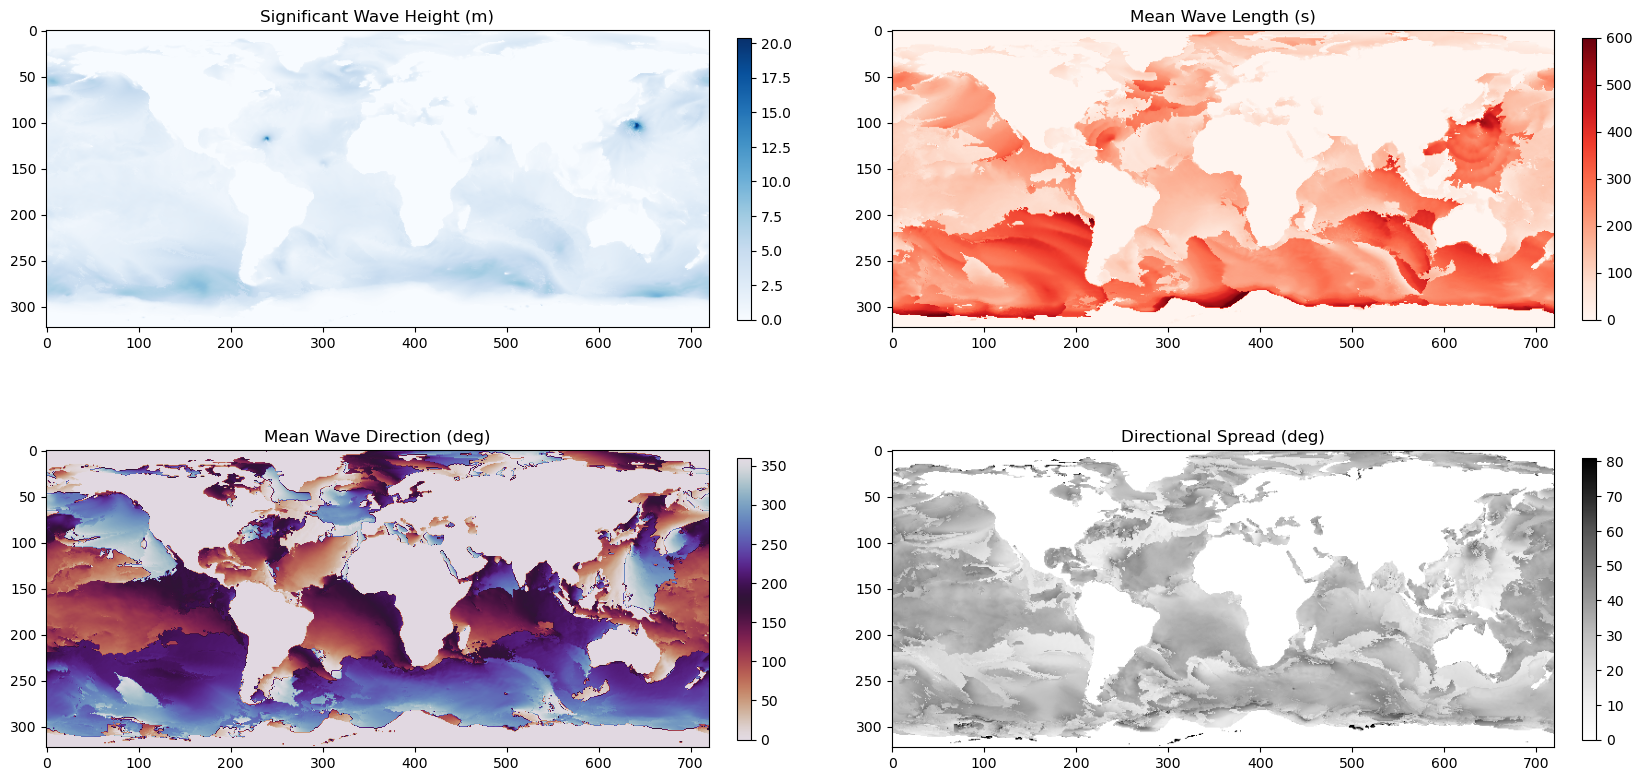

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
img0 = axes[0,0].imshow(wave_max[-1][0][::-1], cmap='Blues')
img1 = axes[0,1].imshow(wave_max[-1][1][::-1], vmin=0, vmax=600, cmap='Reds')
img2 = axes[1,0].imshow(wave_max[-1][2][::-1], cmap='twilight_r')
img3 = axes[1,1].imshow(wave_max[-1][3][::-1], cmap='Greys')
plt.colorbar(img0, ax=axes[0,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[0,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[1,0], fraction=0.02, pad=0.04)
plt.colorbar(img3, ax=axes[1,1], fraction=0.02, pad=0.04)
axes[0,0].set_title('Significant Wave Height (m)')
axes[0,1].set_title('Mean Wave Length (m)')
axes[1,0].set_title('Mean Wave Direction (deg)')
axes[1,1].set_title('Directional Spread (deg)')

### Save mean wave fields

In [ ]:
### Generate mean data
ds_all = xr.open_dataset('/Users/jwu/Work/Code/wavecnn/data/LOPS_WW3-GLOB-30M_202109.nc')
hs_mean = ds_all.hs.values
lp_mean = ds_all.lm.values
dir_mean = ds_all.dir.values
spr_mean = ds_all.spr.values
mean = np.stack([hs_mean, lp_mean, dir_mean, spr_mean], axis=0)
mean = np.swapaxes(mean, 0, 1)
np.save('wave_mean.npy', mean)

Text(0.5, 1.0, 'Directional Spread (deg)')

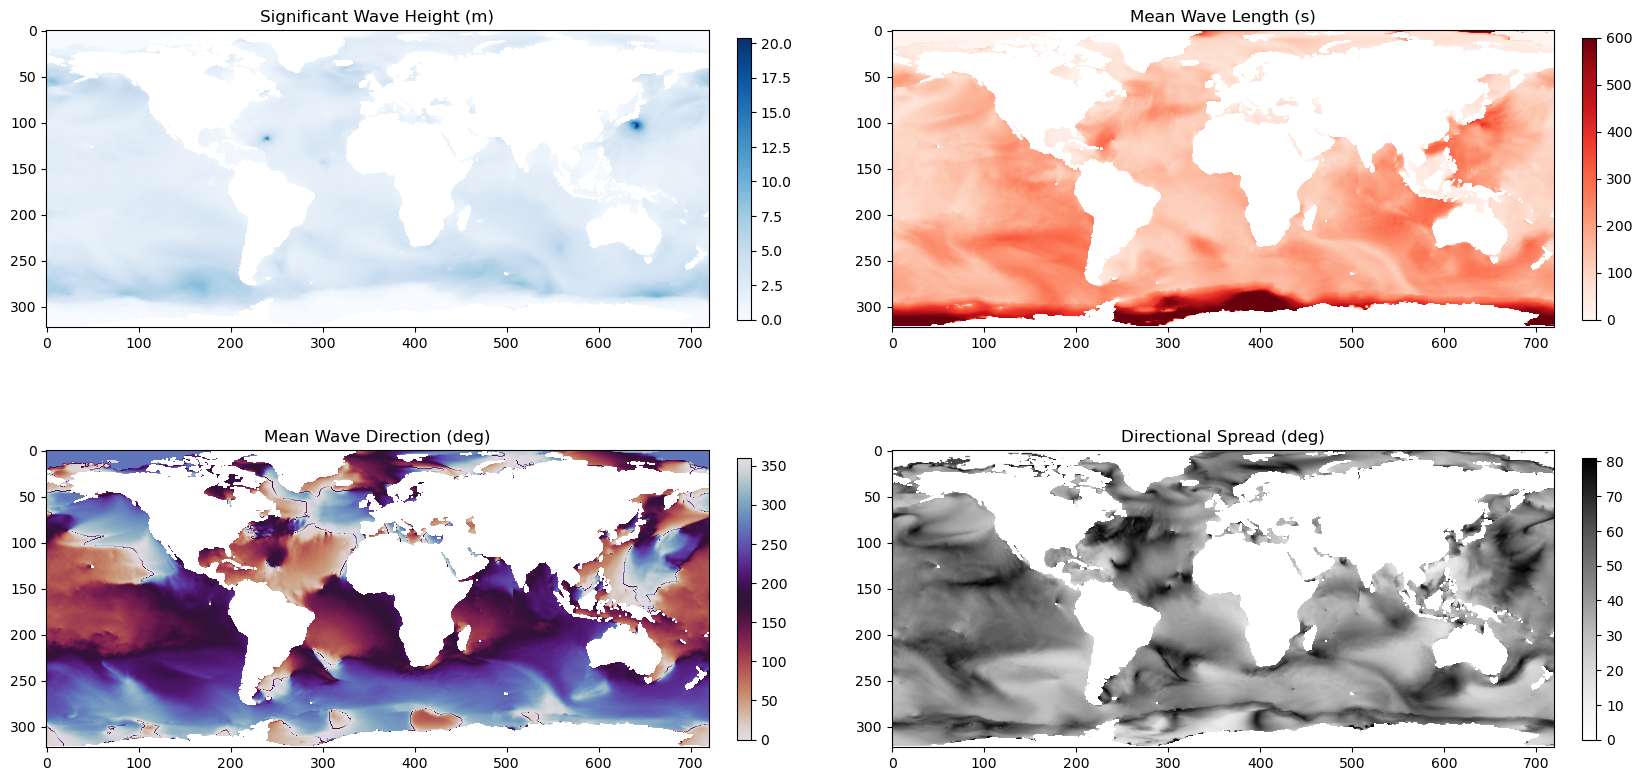

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
img0 = axes[0,0].imshow(mean[-1][0][::-1], cmap='Blues')
img1 = axes[0,1].imshow(mean[-1][1][::-1], vmin=0, vmax=600, cmap='Reds')
img2 = axes[1,0].imshow(mean[-1][2][::-1], cmap='twilight_r')
img3 = axes[1,1].imshow(mean[-1][3][::-1], cmap='Greys')
plt.colorbar(img0, ax=axes[0,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[0,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[1,0], fraction=0.02, pad=0.04)
plt.colorbar(img3, ax=axes[1,1], fraction=0.02, pad=0.04)
axes[0,0].set_title('Significant Wave Height (m)')
axes[0,1].set_title('Mean Wave Length (m)')
axes[1,0].set_title('Mean Wave Direction (deg)')
axes[1,1].set_title('Directional Spread (deg)')

### Save forcing

In [9]:
ds = xr.open_dataset('/Users/jwu/Work/Code/wavecnn/data/202109.nc')

In [ ]:
forcing = np.stack([ds.uwnd.values, ds.vwnd.values, ds.dpt.values, ds.ice.values], axis=0)
np.save('forcing.npy', np.swapaxes(forcing, 0, 1))

### Check resizing

In [ ]:
from torchvision import transforms
import torch
transform = transforms.Resize((320, 320))

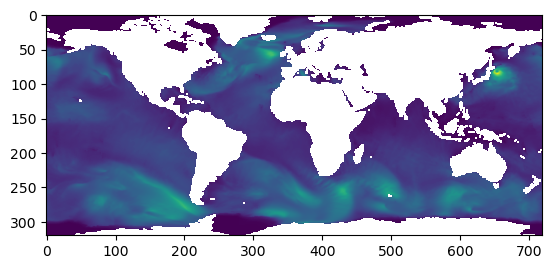

In [ ]:
a = np.load('../datasets/wave_mean.npy')
b = a[:2, :, 1:-2,:]
print(b.shape)
plt.imshow(b[::-1])

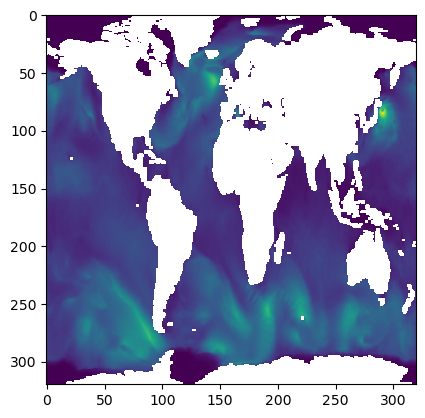

In [ ]:
b_resized = transform(torch.tensor(b))
b_ = b_resized[0,0,:,:].numpy()
plt.imshow(b_[::-1])

In [4]:
mask = np.load('../datasets/mask.npy')
mask = mask[1:-2,:]
mask = mask.reshape(1, 1, mask.shape[0], mask.shape[1])

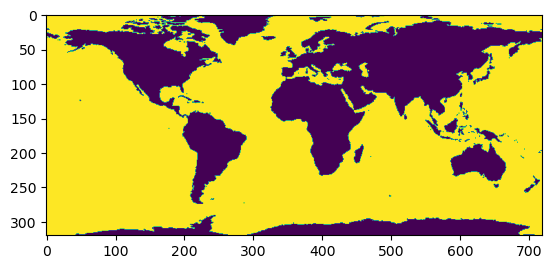

In [5]:
plt.imshow(mask[0,0,::-1])

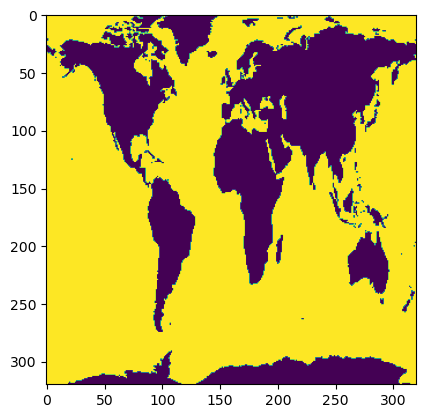

In [7]:
mask_resized = transform(torch.tensor(mask))
mask_ = mask_resized[0,0,:,:].numpy()
plt.imshow(mask_[::-1])

### Latitude weighting

In [2]:
ds = xr.open_dataset('/global/homes/j/jiarongw/scratch_folder/wave_data/raw/LOPS_WW3-GLOB-30M_202109.nc')

In [19]:
lat = np.deg2rad(ds.latitude[1:-2].values)
wlat = np.cos(lat) / np.average(np.cos(lat))
wlat = np.repeat(wlat[:, None], 720, axis=1)
np.save('/global/homes/j/jiarongw/scratch_folder/wave_data/wlat.npy', wlat)

### Partition

In [18]:
ds = xr.open_dataset('/global/homes/j/jiarongw/scratch_folder/wave_data/raw/LOPS_WW3-GLOB-30M_200401.nc')

In [19]:
ds

<xarray.Dataset> Size: 20GB
Dimensions:    (latitude: 323, longitude: 720, time: 248)
Coordinates:
  * latitude   (latitude) float32 1kB -78.0 -77.5 -77.0 -76.5 ... 82.0 82.5 83.0
  * longitude  (longitude) float32 3kB -180.0 -179.5 -179.0 ... 179.0 179.5
  * time       (time) datetime64[ns] 2kB 2004-01-01 ... 2004-01-31T21:00:00
Data variables: (12/86)
    MAPSTA     (latitude, longitude) int16 465kB ...
    dpt        (time, latitude, longitude) float32 231MB ...
    ucur       (time, latitude, longitude) float32 231MB ...
    vcur       (time, latitude, longitude) float32 231MB ...
    uwnd       (time, latitude, longitude) float32 231MB ...
    vwnd       (time, latitude, longitude) float32 231MB ...
    ...         ...
    vabr       (time, latitude, longitude) float32 231MB ...
    uubr       (time, latitude, longitude) float32 231MB ...
    vubr       (time, latitude, longitude) float32 231MB ...
    mssu       (time, latitude, longitude) float32 231MB ...
    mssc       (time, latitude, longitude) float32 231MB ...
    mssd       (time, latitude, longitude) float32 231MB ...
Attributes: (12/102)
    WAVEWATCH_III_version_number:     7.00
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SCRIP SCRIPNC SHRD PR3 UQ...
    SIN4 namelist parameter BETAMAX:  1.75
    title:                            WAVEWATCH-III HINDCAST
    netcdf_version:                   4.5.2
    product_name:                     LOPS_WW3-GLOB-30M_200401.nc
    ...                               ...
    P2SF:                             1
    E3D:                              1
    I1P2SF:                           3
    I2P2SF:                           24
    start_date:                       2004-01-01 00:00:00
    stop_date:                        2004-01-31 21:00:00

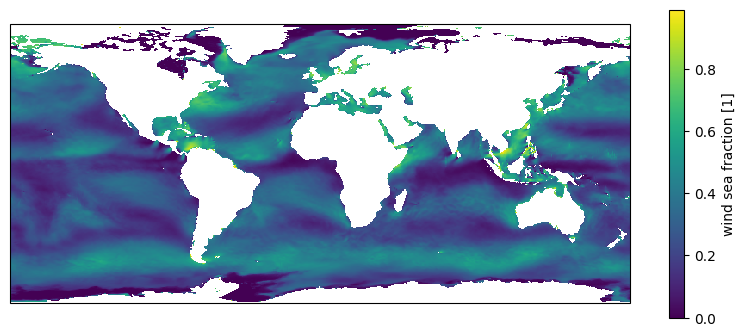

In [14]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[10,4])
ds.tws.mean(dim='time').plot(ax=ax, transform=ccrs.PlateCarree())

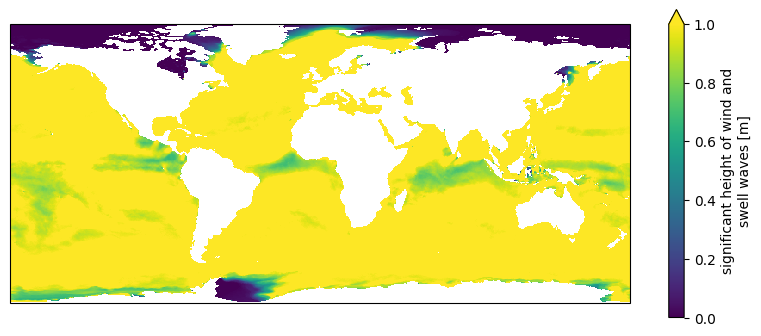

In [ ]:
# Important to fill nan 
for i in range(0, 6):
    ds[f"phs{i}"] = ds[f"phs{i}"].fillna(0)
frac = (ds.phs0 + ds.phs1) / (ds.hs + 1e-3)
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[10,4])
frac.mean(dim='time').plot(ax=ax, vmax=1, vmin=0, transform=ccrs.PlateCarree())
# ds.tws.mean(dim='time').plot(ax=ax, transform=ccrs.PlateCarree())

In [ ]:
from utils import get_top2_indices
ds, idx1, idx2 = get_top2_indices(ds)

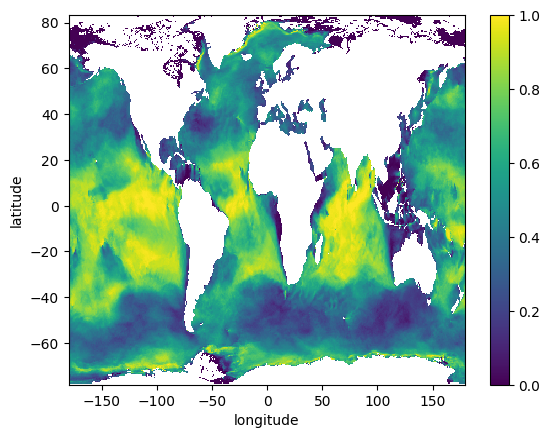

In [50]:
import copy
cmap = copy.copy(plt.get_cmap("viridis"))
cmap.set_bad(color='white')  # Set NaNs to red

# Wave height ratio
ratio = ds.hs_p2 / ds.hs_p1
# Direction difference
dir_diff = abs(ds.dir_p1 - ds.dir_p2)
dir_diff = xr.where(dir_diff <= 180, dir_diff, 360 - dir_diff)

# Crossing sea criterion? 
crossing = xr.where((dir_diff >= 40) & (ratio > 0.5), 1, 0)
# Re-apply land (ice) mask
crossing_masked = crossing.where((ds.ice < 0.9).values) 

# Instantaneous map
# crossing_masked.isel(time=0).plot(cmap=cmap) 
# Monthly averaged map
crossing_masked.mean(dim='time').plot(cmap=cmap)

In [5]:
from utils import get_top2_indices
def read_2par (readpath='/scratch/jw8736/wavecnn/data/', year=2008, month=1):
    # Important! Need to fill nan with 0 for phs{i} before calling get_top2_indices
    ds = xr.open_dataset(readpath + f'LOPS_WW3-GLOB-30M_{year:04d}{month:02d}.nc')
    for i in range(0, 6):
        ds[f"phs{i}"] = ds[f"phs{i}"].fillna(0)
        
    ds, idx1, idx2 = get_top2_indices(ds)
    # Wave height ratio
    ratio = ds.hs_p2 / ds.hs_p1
    # Direction difference
    dir_diff = abs(ds.dir_p1 - ds.dir_p2)
    dir_diff = xr.where(dir_diff <= 180, dir_diff, 360 - dir_diff)
    # Crossing sea criterion? 40 degree direction difference and 0.5 height ratio
    crossing = xr.where((dir_diff >= 40) & (ratio > 0.5), 1, 0)
    # Re-apply land (ice) mask
    crossing_masked = crossing.where((ds.ice < 0.1).values) 
    parts = np.stack([ds.hs_p1.values, ds.tp_p1.values, ds.dir_p1.values,
                      ds.hs_p2.values, ds.tp_p2.values, ds.dir_p2.values,
                      crossing_masked.values], axis=0)
    parts = np.swapaxes(parts, 0, 1)
    return parts

In [6]:
readpath = '/global/homes/j/jiarongw/scratch_folder/wave_data/raw/'
savepath = '/global/homes/j/jiarongw/scratch_folder/wave_data/stokes_global/'
year = 2001
month = 1
parts = read_2par (readpath, year, month)